#  Data Warehouse — Extracción del Conocimiento de Base de Datos
## Creación e Implementación con PostgreSQL y Python
# **Universidad Tecnológica del Centro de Veracruz**
# **Producto 1er Parcial**
# **Vichique Hernandez Eduardo Adan**


---
## 1. Instalación de Dependencias

In [42]:
# Instalar librerías necesarias
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'sqlalchemy', 'psycopg2-binary',
                'matplotlib', 'seaborn', 'faker', 'ipython-sql'], capture_output=True)
print(' Dependencias instaladas correctamente')

 Dependencias instaladas correctamente


---
## 2. Configuración de la Conexión a PostgreSQL

In [43]:
import pandas as pd
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# ─── CONFIGURACIÓN ────────────────────────────────────────
DB_USER     = 'postgres'
DB_PASSWORD = '181118'   
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'dw_ventas'
# ──────────────────────────────────────────────────────────
# Primero conectar a postgres para crear la base de datos si no existe
engine_default = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/postgres',
    isolation_level='AUTOCOMMIT'
)

with engine_default.connect() as conn:
    result = conn.execute(text("SELECT 1 FROM pg_database WHERE datname = 'dw_ventas'"))
    if not result.fetchone():
        conn.execute(text('CREATE DATABASE dw_ventas'))
        print(' Base de datos dw_ventas creada')
    else:
        print('  Base de datos dw_ventas ya existe')
# Conectar al DW
engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)
print(f' Conectado a {DB_NAME} en {DB_HOST}:{DB_PORT}')

  Base de datos dw_ventas ya existe
 Conectado a dw_ventas en localhost:5432


---
## 3. Diseño del Modelo Dimensional 

El Data Warehouse utiliza un esquema estrella con las siguientes tablas:

```
                    ┌─────────────┐
                    │  dim_tiempo │
                    └──────┬──────┘
                           │
┌──────────────┐    ┌──────┴──────┐    ┌───────────────┐
│  dim_cliente ├────┤ fact_ventas ├────┤  dim_producto  │
└──────────────┘    └──────┬──────┘    └───────────────┘
                           │
                    ┌──────┴──────┐
                    │  dim_region │
                    └─────────────┘
```

---
## 4. Creación de Tablas de Dimensión y Hechos

In [44]:
DDL = """
-- ══════════════════════════════════════════════
--  TABLAS DE DIMENSIÓN
-- ══════════════════════════════════════════════

CREATE TABLE IF NOT EXISTS dim_tiempo (
    tiempo_id   SERIAL PRIMARY KEY,
    fecha       DATE        NOT NULL UNIQUE,
    dia         INT         NOT NULL,
    mes         INT         NOT NULL,
    anio        INT         NOT NULL,
    trimestre   INT         NOT NULL,
    nombre_mes  VARCHAR(20) NOT NULL,
    dia_semana  VARCHAR(20) NOT NULL,
    es_fin_semana BOOLEAN   NOT NULL
);

CREATE TABLE IF NOT EXISTS dim_cliente (
    cliente_id  SERIAL PRIMARY KEY,
    nombre      VARCHAR(100) NOT NULL,
    correo      VARCHAR(120),
    telefono    VARCHAR(20),
    ciudad      VARCHAR(80),
    estado      VARCHAR(80),
    segmento    VARCHAR(40)   -- 'Minorista', 'Mayorista', 'Corporativo'
);

CREATE TABLE IF NOT EXISTS dim_producto (
    producto_id SERIAL PRIMARY KEY,
    nombre      VARCHAR(120) NOT NULL,
    categoria   VARCHAR(60)  NOT NULL,
    subcategoria VARCHAR(60),
    marca       VARCHAR(60),
    precio_unitario NUMERIC(10,2) NOT NULL
);

CREATE TABLE IF NOT EXISTS dim_region (
    region_id   SERIAL PRIMARY KEY,
    nombre      VARCHAR(60)  NOT NULL,
    pais        VARCHAR(60)  NOT NULL DEFAULT 'México',
    zona        VARCHAR(40)  -- 'Norte', 'Sur', 'Centro', 'Occidente'
);

-- ══════════════════════════════════════════════
--  TABLA DE HECHOS
-- ══════════════════════════════════════════════

CREATE TABLE IF NOT EXISTS fact_ventas (
    venta_id    SERIAL PRIMARY KEY,
    tiempo_id   INT  REFERENCES dim_tiempo(tiempo_id),
    cliente_id  INT  REFERENCES dim_cliente(cliente_id),
    producto_id INT  REFERENCES dim_producto(producto_id),
    region_id   INT  REFERENCES dim_region(region_id),
    cantidad    INT          NOT NULL,
    precio_venta    NUMERIC(10,2) NOT NULL,
    descuento       NUMERIC(5,2)  DEFAULT 0,
    monto_total     NUMERIC(12,2) NOT NULL,
    costo_total     NUMERIC(12,2),
    ganancia        NUMERIC(12,2)
);
"""

with engine.connect() as conn:
    conn.execute(text(DDL))
    conn.commit()

print(' Tablas creadas exitosamente:')
print('    dim_tiempo')
print('    dim_cliente')
print('    dim_producto')
print('     dim_region')
print('    fact_ventas')

 Tablas creadas exitosamente:
    dim_tiempo
    dim_cliente
    dim_producto
     dim_region
    fact_ventas


---
## 5. Generación y Carga de Datos (ETL)

### 5.1 Generación de CSVs simulados

In [45]:
import pandas as pd
import numpy as np
import os
from datetime import date, timedelta
import random

random.seed(42)
np.random.seed(42)
os.makedirs('data', exist_ok=True)

# ── dim_tiempo ──────────────────────────────────
fechas = pd.date_range('2022-01-01', '2024-12-31', freq='D')
meses_es = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
            'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
dias_es  = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

df_tiempo = pd.DataFrame({
    'fecha':         fechas,
    'dia':           fechas.day,
    'mes':           fechas.month,
    'anio':          fechas.year,
    'trimestre':     fechas.quarter,
    'nombre_mes':    [meses_es[m-1] for m in fechas.month],
    'dia_semana':    [dias_es[d] for d in fechas.dayofweek],
    'es_fin_semana': fechas.dayofweek >= 5
})
df_tiempo.to_csv('data/dim_tiempo.csv', index=False)

# ── dim_region ──────────────────────────────────
regiones = [
    ('Ciudad de México', 'Centro'), ('Jalisco', 'Occidente'),
    ('Nuevo León', 'Norte'),        ('Veracruz', 'Sur'),
    ('Puebla', 'Centro'),           ('Guanajuato', 'Centro'),
    ('Yucatán', 'Sur'),             ('Chihuahua', 'Norte'),
    ('Sonora', 'Norte'),            ('Oaxaca', 'Sur')
]
df_region = pd.DataFrame(regiones, columns=['nombre','zona'])
df_region['pais'] = 'México'
df_region.to_csv('data/dim_region.csv', index=False)

# ── dim_producto ────────────────────────────────
categorias = {
    'Electrónica':  [('Laptop HP 15"','Computadoras','HP',12500),
                     ('Monitor LG 24"','Monitores','LG',3800),
                     ('Teclado Logitech','Periféricos','Logitech',650),
                     ('Mouse Inalámbrico','Periféricos','Logitech',450),
                     ('Audífonos Sony','Audio','Sony',1200)],
    'Muebles':      [('Silla Ergonómica','Oficina','OfficeMax',2800),
                     ('Escritorio L','Oficina','IKEA',4500),
                     ('Estantería Metálica','Almacenaje','IKEA',1900)],
    'Papelería':    [('Resma de Papel','Insumos','Buro',180),
                     ('Bolígrafos x12','Escritura','Pilot',95),
                     ('Carpeta Archivadora','Organización','Leitz',120)],
    'Software':     [('Licencia Office 365','Productividad','Microsoft',3200),
                     ('Antivirus Plus','Seguridad','Norton',850)]
}

rows = []
for cat, items in categorias.items():
    for nombre, subcat, marca, precio in items:
        rows.append({'nombre': nombre, 'categoria': cat, 'subcategoria': subcat,
                     'marca': marca, 'precio_unitario': precio})
df_producto = pd.DataFrame(rows)
df_producto.to_csv('data/dim_producto.csv', index=False)

# ── dim_cliente ─────────────────────────────────
segmentos = ['Minorista', 'Mayorista', 'Corporativo']
estados_mx = [r[0] for r in regiones]
nombres = [
    'Ana García','Carlos López','María Hernández','José Martínez',
    'Laura Sánchez','Miguel Rodríguez','Sofía Torres','Luis Ramírez',
    'Fernanda Cruz','Roberto Morales','Alejandra Reyes','Eduardo Jiménez',
    'Patricia Flores','Arturo Vargas','Daniela Guzmán','Sergio Mendoza',
    'Claudia Ortiz','Rafael Herrera','Valeria Peña','Andrés Castillo'
]
df_cliente = pd.DataFrame({
    'nombre':    nombres,
    'correo':    [f"{n.lower().replace(' ','.')}{i}@email.com" for i,n in enumerate(nombres)],
    'telefono':  [f"55{random.randint(10000000,99999999)}" for _ in nombres],
    'ciudad':    [random.choice(estados_mx) for _ in nombres],
    'estado':    [random.choice(estados_mx) for _ in nombres],
    'segmento':  [random.choice(segmentos) for _ in nombres]
})
df_cliente.to_csv('data/dim_cliente.csv', index=False)

print(f' CSVs generados en /data:')
for f in os.listdir('data'):
    df = pd.read_csv(f'data/{f}')
    print(f'    {f}: {len(df)} registros')

 CSVs generados en /data:
    dim_cliente.csv: 20 registros
    dim_producto.csv: 13 registros
    dim_region.csv: 10 registros
    dim_tiempo.csv: 1096 registros
    fact_ventas.csv: 2000 registros


### 5.2 Carga de dimensiones a PostgreSQL

In [46]:
# Función ETL genérica
def cargar_dimension(df, tabla, engine, truncate=True):
    with engine.connect() as conn:
        if truncate:
            conn.execute(text(f'TRUNCATE TABLE {tabla} RESTART IDENTITY CASCADE'))
            conn.commit()
    df.to_sql(tabla, engine, if_exists='append', index=False, method='multi', chunksize=500)
    print(f'   {tabla}: {len(df)} registros cargados')

print(' Cargando dimensiones...')
cargar_dimension(pd.read_csv('data/dim_tiempo.csv'),   'dim_tiempo',   engine)
cargar_dimension(pd.read_csv('data/dim_region.csv'),   'dim_region',   engine)
cargar_dimension(pd.read_csv('data/dim_producto.csv'), 'dim_producto', engine)
cargar_dimension(pd.read_csv('data/dim_cliente.csv'),  'dim_cliente',  engine)
print('\n Dimensiones cargadas correctamente')

 Cargando dimensiones...
   dim_tiempo: 1096 registros cargados
   dim_region: 10 registros cargados
   dim_producto: 13 registros cargados
   dim_cliente: 20 registros cargados

 Dimensiones cargadas correctamente


### 5.3 Generación y carga de la tabla de hechos

In [47]:
# Leer IDs desde la BD para asegurar integridad referencial
with engine.connect() as conn:
    ids_tiempo   = [r[0] for r in conn.execute(text('SELECT tiempo_id FROM dim_tiempo')).fetchall()]
    ids_cliente  = [r[0] for r in conn.execute(text('SELECT cliente_id FROM dim_cliente')).fetchall()]
    ids_producto = [r[0] for r in conn.execute(text('SELECT producto_id, precio_unitario FROM dim_producto')).fetchall()]
    ids_region   = [r[0] for r in conn.execute(text('SELECT region_id FROM dim_region')).fetchall()]

# Cargar precios reales
df_precios = pd.read_sql('SELECT producto_id, precio_unitario FROM dim_producto', engine)
precio_map = dict(zip(df_precios.producto_id, df_precios.precio_unitario))

# Generar 2000 transacciones de ventas
N = 2000
prod_ids  = np.random.choice([p for p, _ in ids_producto] if isinstance(ids_producto[0], tuple) 
                              else list(precio_map.keys()), N)
cantidades = np.random.randint(1, 15, N)
descuentos = np.random.choice([0, 0, 0, 5, 10, 15, 20], N)  # mayoría sin descuento

precios_venta = np.array([float(precio_map[p]) for p in prod_ids])
montos = cantidades * precios_venta * (1 - descuentos/100)
costos = montos * np.random.uniform(0.55, 0.75, N)  # margen 25–45%

df_fact = pd.DataFrame({
    'tiempo_id':   np.random.choice(ids_tiempo,  N),
    'cliente_id':  np.random.choice(ids_cliente, N),
    'producto_id': prod_ids,
    'region_id':   np.random.choice(ids_region,  N),
    'cantidad':    cantidades,
    'precio_venta':  precios_venta.round(2),
    'descuento':     descuentos.astype(float),
    'monto_total':   montos.round(2),
    'costo_total':   costos.round(2),
    'ganancia':      (montos - costos).round(2)
})

df_fact.to_csv('data/fact_ventas.csv', index=False)

with engine.connect() as conn:
    conn.execute(text('TRUNCATE TABLE fact_ventas RESTART IDENTITY'))
    conn.commit()

df_fact.to_sql('fact_ventas', engine, if_exists='append', index=False, method='multi', chunksize=500)
print(f' fact_ventas: {len(df_fact)} registros cargados')
print(f'    Monto total cargado: ${df_fact.monto_total.sum():,.2f}')

 fact_ventas: 2000 registros cargados
    Monto total cargado: $36,913,035.75


---
## 6. Consultas SQL y Análisis con Pandas

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

print(' Librerías de visualización listas')

 Librerías de visualización listas


### 6.1 Ventas totales por año

 anio  num_transacciones  ventas_totales  ganancia_total
 2022                645     12600624.00      4510859.47
 2023                668     11410440.00      4014916.61
 2024                687     12901971.75      4550600.63


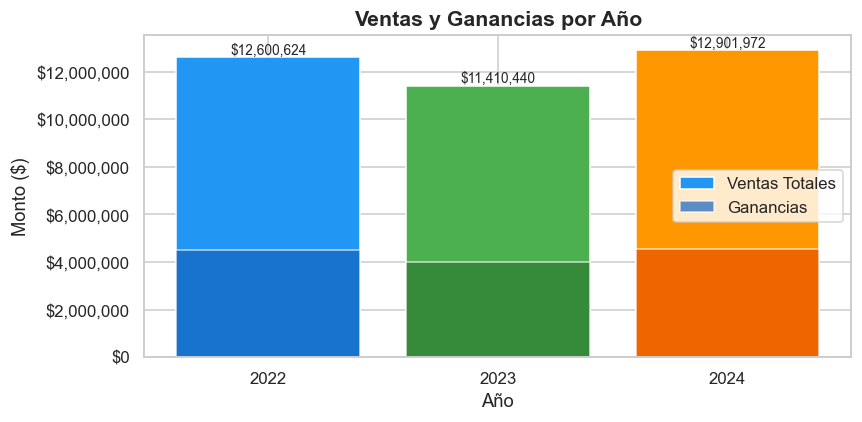

In [49]:
sql_anio = """
SELECT t.anio, 
       COUNT(*) AS num_transacciones,
       SUM(f.monto_total) AS ventas_totales,
       SUM(f.ganancia)    AS ganancia_total
FROM fact_ventas f
JOIN dim_tiempo  t ON f.tiempo_id = t.tiempo_id
GROUP BY t.anio
ORDER BY t.anio;
"""
df_anio = pd.read_sql(sql_anio, engine)
print(df_anio.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(df_anio.anio.astype(str), df_anio.ventas_totales, color=['#2196F3','#4CAF50','#FF9800'])
ax.bar(df_anio.anio.astype(str), df_anio.ganancia_total, color=['#1565C0','#2E7D32','#E65100'], 
       alpha=0.7, label='Ganancia')
ax.set_title('Ventas y Ganancias por Año', fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Monto ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(['Ventas Totales','Ganancias'])
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000, 
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

### 6.2 Top 5 productos más vendidos

             nombre   categoria  unidades_vendidas  ingresos_totales
      Laptop HP 15" Electrónica               1341        15696875.0
       Escritorio L     Muebles               1177         4932900.0
     Monitor LG 24" Electrónica               1109         3928820.0
Licencia Office 365    Software               1226         3669920.0
   Silla Ergonómica     Muebles               1113         2916900.0


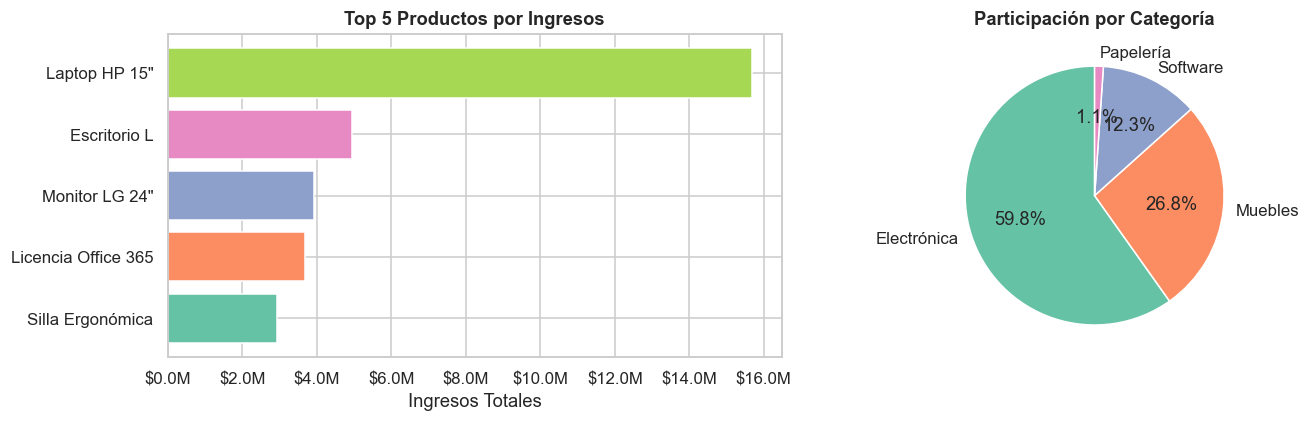

In [50]:
sql_prod = """
SELECT p.nombre, p.categoria,
       SUM(f.cantidad)    AS unidades_vendidas,
       SUM(f.monto_total) AS ingresos_totales
FROM fact_ventas f
JOIN dim_producto p ON f.producto_id = p.producto_id
GROUP BY p.nombre, p.categoria
ORDER BY ingresos_totales DESC
LIMIT 5;
"""
df_prod = pd.read_sql(sql_prod, engine)
print(df_prod.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras horizontales — ingresos
colores = sns.color_palette('Set2', 5)
axes[0].barh(df_prod.nombre[::-1], df_prod.ingresos_totales[::-1], color=colores)
axes[0].set_title('Top 5 Productos por Ingresos', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].set_xlabel('Ingresos Totales')

# Pastel — distribución de ingresos por categoría
sql_cat = """
SELECT p.categoria, SUM(f.monto_total) AS total
FROM fact_ventas f
JOIN dim_producto p ON f.producto_id = p.producto_id
GROUP BY p.categoria ORDER BY total DESC;
"""
df_cat = pd.read_sql(sql_cat, engine)
axes[1].pie(df_cat.total, labels=df_cat.categoria, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(df_cat)), startangle=90)
axes[1].set_title('Participación por Categoría', fontweight='bold')

plt.tight_layout(); plt.show()

### 6.3 Ventas por región

          region      zona     ventas   ganancia  transacciones
      Guanajuato    Centro 4606294.25 1660975.72            215
         Jalisco Occidente 4007731.75 1427482.45            196
       Chihuahua     Norte 3853294.00 1364127.79            213
        Veracruz       Sur 3843086.50 1375135.29            203
Ciudad de México    Centro 3700778.75 1302374.78            194
          Puebla    Centro 3615819.75 1209416.90            204
         Yucatán       Sur 3575951.75 1259354.07            200
      Nuevo León     Norte 3552771.00 1234048.29            192
          Oaxaca       Sur 3405678.75 1263395.83            196
          Sonora     Norte 2751629.25  980065.59            187


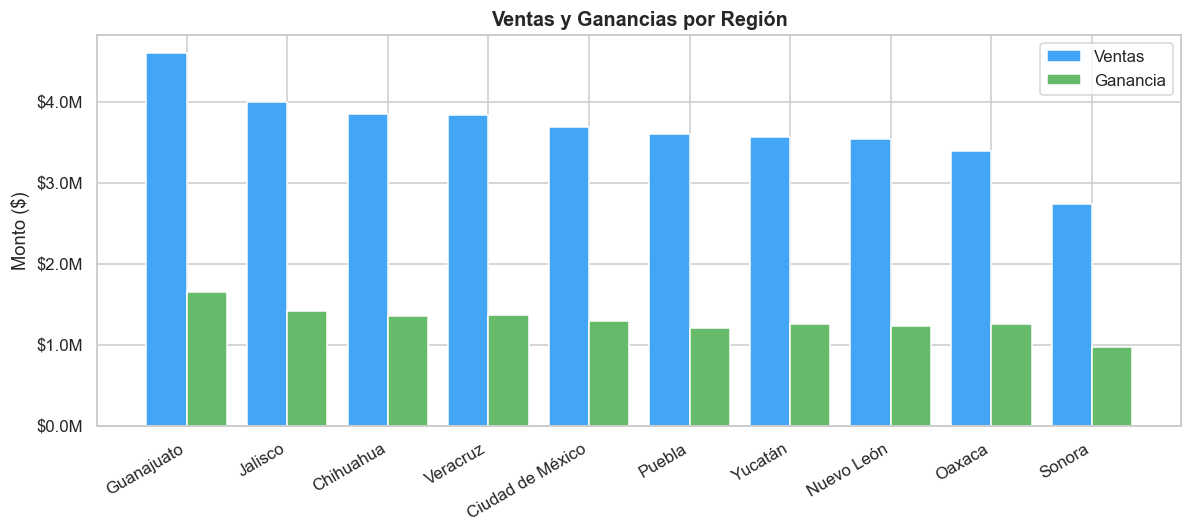

In [51]:
sql_region = """
SELECT r.nombre AS region, r.zona,
       SUM(f.monto_total) AS ventas,
       SUM(f.ganancia)    AS ganancia,
       COUNT(*)           AS transacciones
FROM fact_ventas f
JOIN dim_region r ON f.region_id = r.region_id
GROUP BY r.nombre, r.zona
ORDER BY ventas DESC;
"""
df_reg = pd.read_sql(sql_region, engine)
print(df_reg.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(df_reg))
bars1 = ax.bar([i - 0.2 for i in x], df_reg.ventas,    width=0.4, label='Ventas',   color='#42A5F5')
bars2 = ax.bar([i + 0.2 for i in x], df_reg.ganancia,  width=0.4, label='Ganancia', color='#66BB6A')
ax.set_xticks(list(x))
ax.set_xticklabels(df_reg.region, rotation=30, ha='right')
ax.set_title('Ventas y Ganancias por Región', fontsize=13, fontweight='bold')
ax.set_ylabel('Monto ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.legend()
plt.tight_layout(); plt.show()

### 6.4 Tendencia mensual de ventas (2022–2024)

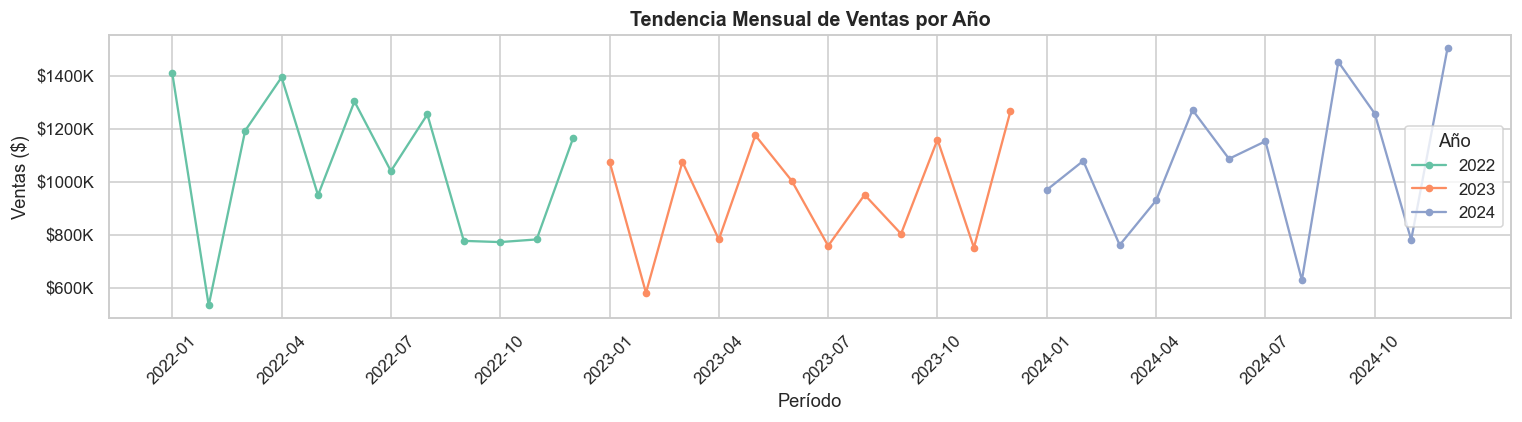

In [52]:
sql_mensual = """
SELECT t.anio, t.mes, t.nombre_mes,
       SUM(f.monto_total) AS ventas
FROM fact_ventas f
JOIN dim_tiempo t ON f.tiempo_id = t.tiempo_id
GROUP BY t.anio, t.mes, t.nombre_mes
ORDER BY t.anio, t.mes;
"""
df_men = pd.read_sql(sql_mensual, engine)
df_men['periodo'] = df_men['anio'].astype(str) + '-' + df_men['mes'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 4))
for anio, grupo in df_men.groupby('anio'):
    ax.plot(grupo.periodo, grupo.ventas, marker='o', markersize=4, label=str(anio))

ax.set_title('Tendencia Mensual de Ventas por Año', fontsize=13, fontweight='bold')
ax.set_xlabel('Período'); ax.set_ylabel('Ventas ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
tick_positions = list(range(0, len(df_men), 3))
ax.set_xticks([df_men.periodo.iloc[i] for i in tick_positions])
ax.set_xticklabels([df_men.periodo.iloc[i] for i in tick_positions], rotation=45)
ax.legend(title='Año')
plt.tight_layout(); plt.show()

### 6.5 Análisis por segmento de cliente


 KPIs por Segmento de Cliente:
   segmento  clientes_activos  ventas_totales  ticket_promedio  margen_%
Corporativo                 7     14696036.25     20159.171811      36.0
  Mayorista                 7     11711986.50     17691.822508      35.7
  Minorista                 6     10505013.00     17249.610837      34.4


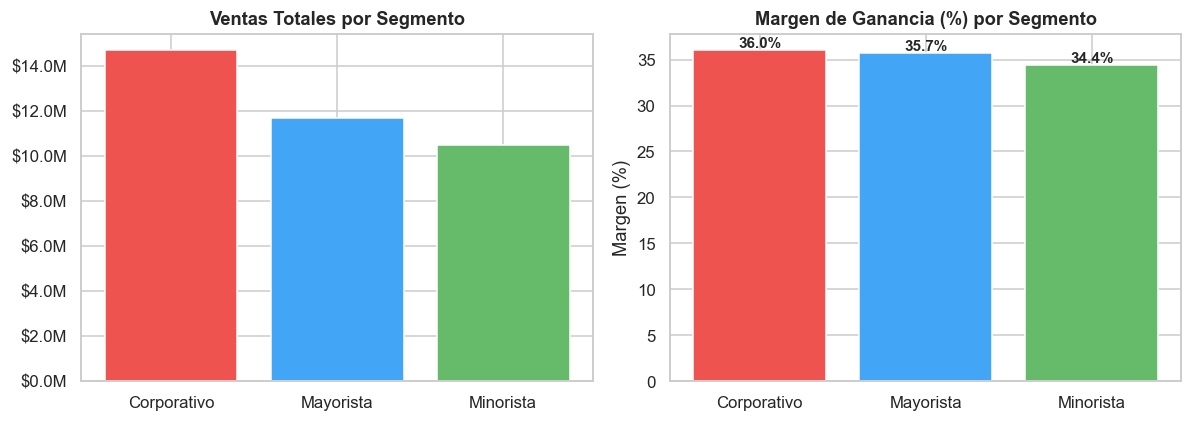

In [53]:
sql_seg = """
SELECT c.segmento,
       COUNT(DISTINCT f.cliente_id) AS clientes_activos,
       SUM(f.monto_total)           AS ventas_totales,
       AVG(f.monto_total)           AS ticket_promedio,
       SUM(f.ganancia)              AS ganancia_total
FROM fact_ventas f
JOIN dim_cliente c ON f.cliente_id = c.cliente_id
GROUP BY c.segmento
ORDER BY ventas_totales DESC;
"""
df_seg = pd.read_sql(sql_seg, engine)
df_seg['margen_%'] = (df_seg.ganancia_total / df_seg.ventas_totales * 100).round(1)

print('\n KPIs por Segmento de Cliente:')
print(df_seg[['segmento','clientes_activos','ventas_totales','ticket_promedio','margen_%']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colores = ['#EF5350','#42A5F5','#66BB6A']

axes[0].bar(df_seg.segmento, df_seg.ventas_totales, color=colores)
axes[0].set_title('Ventas Totales por Segmento', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

axes[1].bar(df_seg.segmento, df_seg['margen_%'], color=colores)
axes[1].set_title('Margen de Ganancia (%) por Segmento', fontweight='bold')
axes[1].set_ylabel('Margen (%)')
for bar, v in zip(axes[1].patches, df_seg['margen_%']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Dashboard Resumen de KPIs

In [54]:
# KPIs generales
kpis = pd.read_sql("""
SELECT
  COUNT(*)                        AS total_transacciones,
  SUM(monto_total)                AS ventas_totales,
  SUM(ganancia)                   AS ganancia_total,
  AVG(monto_total)                AS ticket_promedio,
  ROUND(SUM(ganancia)/SUM(monto_total)*100, 2) AS margen_pct
FROM fact_ventas;
""", engine).iloc[0]

print('=' * 50)
print('          DASHBOARD — KPIs GLOBALES')
print('=' * 50)
print(f'   Transacciones:     {int(kpis.total_transacciones):,}')
print(f'   Ventas totales:    ${kpis.ventas_totales:,.2f}')
print(f'   Ganancia total:    ${kpis.ganancia_total:,.2f}')
print(f'   Ticket promedio:   ${kpis.ticket_promedio:,.2f}')
print(f'   Margen global:     {kpis.margen_pct}%')
print('=' * 50)

          DASHBOARD — KPIs GLOBALES
   Transacciones:     2,000
   Ventas totales:    $36,913,035.75
   Ganancia total:    $13,076,376.71
   Ticket promedio:   $18,456.52
   Margen global:     35.42%
